In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [2]:
import os
os.getcwd()

'C:\\Users\\mma'

In [3]:
os.listdir("credit_project")

['application_data.csv',
 'bureau.csv',
 'bureau_balance.csv',
 'credit_card_balance.csv',
 'installments_payments.csv',
 'POS_CASH_balance.csv',
 'previous_application.csv',
 'sample_submission (1).csv']

In [4]:
application_data = pd.read_csv("credit_project/application_data.csv")
previous_application = pd.read_csv("credit_project/previous_application.csv")

In [5]:
application_data.shape
previous_application.shape

(1670214, 37)

In [6]:
application_data.isnull().sum()

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64

In [7]:
(application_data.isnull().mean()) * 100

SK_ID_CURR                     0.000000
TARGET                         0.000000
NAME_CONTRACT_TYPE             0.000000
CODE_GENDER                    0.000000
FLAG_OWN_CAR                   0.000000
                                ...    
AMT_REQ_CREDIT_BUREAU_DAY     13.501631
AMT_REQ_CREDIT_BUREAU_WEEK    13.501631
AMT_REQ_CREDIT_BUREAU_MON     13.501631
AMT_REQ_CREDIT_BUREAU_QRT     13.501631
AMT_REQ_CREDIT_BUREAU_YEAR    13.501631
Length: 122, dtype: float64

In [8]:
null_percentage = (application_data.isnull().mean()) * 100
null_percentage = null_percentage.sort_values(ascending=False)

null_percentage

COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
                              ...    
FLAG_DOCUMENT_16             0.000000
FLAG_DOCUMENT_15             0.000000
FLAG_DOCUMENT_14             0.000000
FLAG_DOCUMENT_20             0.000000
FLAG_DOCUMENT_21             0.000000
Length: 122, dtype: float64

In [9]:
null_percentage.head(20)

COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
FLOORSMIN_MODE              67.848630
FLOORSMIN_AVG               67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_AVG             66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_MEDI            66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_AVG                59.376738
LANDAREA_MODE               59.376738
dtype: float64

In [10]:
threshold = 49

In [11]:
min_non_null = int(((100 - threshold) / 100) * application_data.shape[0])
min_non_null

156830

In [12]:
application_data = application_data.dropna(axis=1, thresh=min_non_null)

In [13]:
application_data.shape

(307511, 78)

In [14]:
(application_data.isnull().mean() * 100).sort_values(ascending=False).head(20)

YEARS_BEGINEXPLUATATION_MODE    48.781019
YEARS_BEGINEXPLUATATION_AVG     48.781019
YEARS_BEGINEXPLUATATION_MEDI    48.781019
TOTALAREA_MODE                  48.268517
EMERGENCYSTATE_MODE             47.398304
OCCUPATION_TYPE                 31.345545
EXT_SOURCE_3                    19.825307
AMT_REQ_CREDIT_BUREAU_YEAR      13.501631
AMT_REQ_CREDIT_BUREAU_MON       13.501631
AMT_REQ_CREDIT_BUREAU_DAY       13.501631
AMT_REQ_CREDIT_BUREAU_QRT       13.501631
AMT_REQ_CREDIT_BUREAU_WEEK      13.501631
AMT_REQ_CREDIT_BUREAU_HOUR      13.501631
NAME_TYPE_SUITE                  0.420148
DEF_30_CNT_SOCIAL_CIRCLE         0.332021
OBS_30_CNT_SOCIAL_CIRCLE         0.332021
OBS_60_CNT_SOCIAL_CIRCLE         0.332021
DEF_60_CNT_SOCIAL_CIRCLE         0.332021
EXT_SOURCE_2                     0.214626
AMT_GOODS_PRICE                  0.090403
dtype: float64

In [15]:
for col in application_data.columns:
    if application_data[col].dtype in ['int64', 'float64']:
        application_data[col] = application_data[col].abs()

In [16]:
application_data[['DAYS_BIRTH', 'DAYS_EMPLOYED']].head()

,DAYS_BIRTH,DAYS_EMPLOYED
0,9461,637
1,16765,1188
2,19046,225
3,19005,3039
4,19932,3038


In [17]:
application_data['AMT_CREDIT'].describe()

count    3.075110e+05
mean     5.990260e+05
std      4.024908e+05
min      4.500000e+04
25%      2.700000e+05
50%      5.135310e+05
75%      8.086500e+05
max      4.050000e+06
Name: AMT_CREDIT, dtype: float64

In [18]:
credit_bins = [0, 200000, 500000, 1000000, application_data['AMT_CREDIT'].max()]
credit_labels = ['Very Low', 'Low', 'Medium', 'High']

application_data['CREDIT_CATEGORY'] = pd.cut(application_data['AMT_CREDIT'],
                                             bins=credit_bins,
                                             labels=credit_labels)

In [19]:
application_data['CREDIT_CATEGORY'].value_counts()

CREDIT_CATEGORY
Low         113189
Medium      108193
High         49985
Very Low     36144
Name: count, dtype: int64

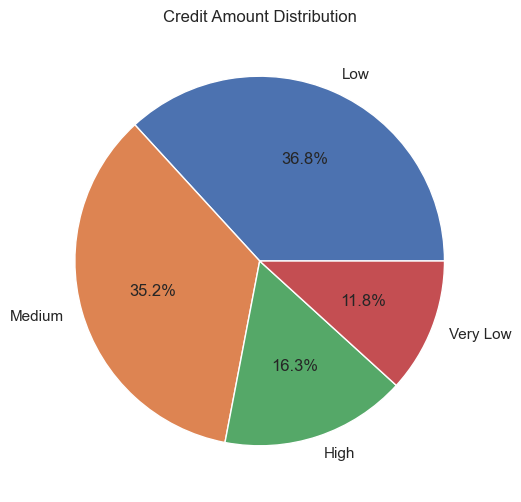

In [20]:
application_data['CREDIT_CATEGORY'].value_counts().plot.pie(
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Credit Amount Distribution")
plt.ylabel('')
plt.show()

In [21]:
application_data['AMT_GOODS_PRICE'].describe()

count    3.072330e+05
mean     5.383962e+05
std      3.694465e+05
min      4.050000e+04
25%      2.385000e+05
50%      4.500000e+05
75%      6.795000e+05
max      4.050000e+06
Name: AMT_GOODS_PRICE, dtype: float64

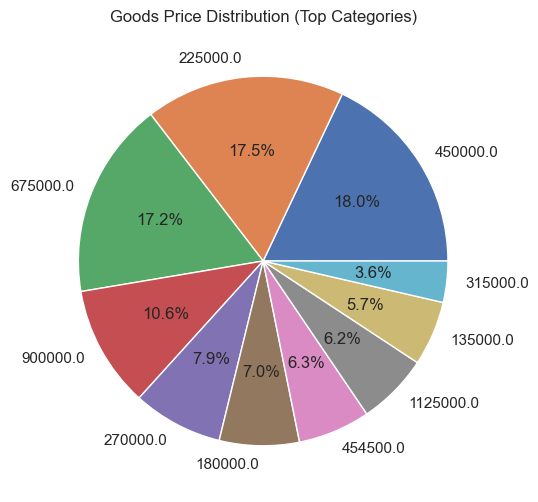

In [22]:
application_data['AMT_GOODS_PRICE'].value_counts().head(10).plot.pie(
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Goods Price Distribution (Top Categories)")
plt.ylabel('')
plt.show()

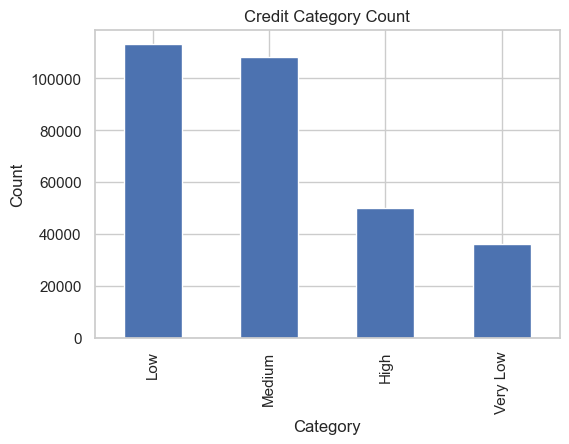

In [23]:
application_data['CREDIT_CATEGORY'].value_counts().plot(kind='bar', figsize=(6,4))

plt.title("Credit Category Count")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

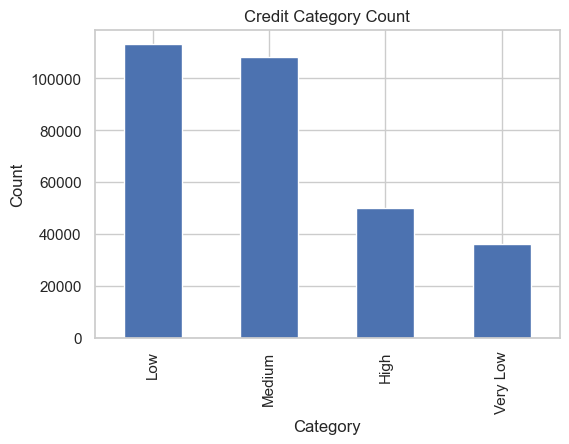

In [24]:
application_data['CREDIT_CATEGORY'].value_counts().plot(kind='bar', figsize=(6,4))

plt.title("Credit Category Count")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

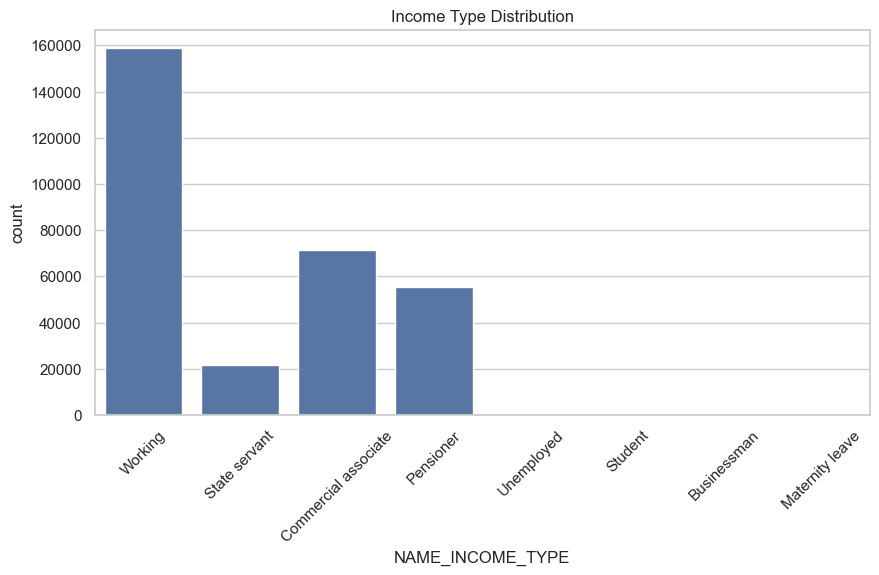

In [25]:
plt.figure(figsize=(10,5))
sns.countplot(x='NAME_INCOME_TYPE', data=application_data)

plt.xticks(rotation=45)
plt.title("Income Type Distribution")
plt.show()

In [26]:
## Univariate Analysis

In [36]:
cat_cols = application_data.select_dtypes(include=['object']).columns
cat_cols

C:\Users\mma\AppData\Local\Temp\ipykernel_13680\4074940046.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = application_data.select_dtypes(include=['object']).columns


Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE',
       'EMERGENCYSTATE_MODE'],
      dtype='str')

In [37]:
def categorical_analysis(df, col):
    print(f"\n🔹 Column: {col}")
    
    # Value counts (percentage)
    value_perc = df[col].value_counts(normalize=True) * 100
    print(value_perc)
    
    # Pie Chart
    plt.figure(figsize=(6,6))
    value_perc.plot.pie(autopct='%1.1f%%')
    plt.title(f"{col} Distribution")
    plt.ylabel('')
    plt.show()
    
    # Bar Plot
    plt.figure(figsize=(6,4))
    value_perc.plot(kind='bar')
    plt.title(f"{col} Count Distribution")
    plt.xlabel(col)
    plt.ylabel('Percentage')
    plt.xticks(rotation=45)
    plt.show()


🔹 Column: TARGET
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


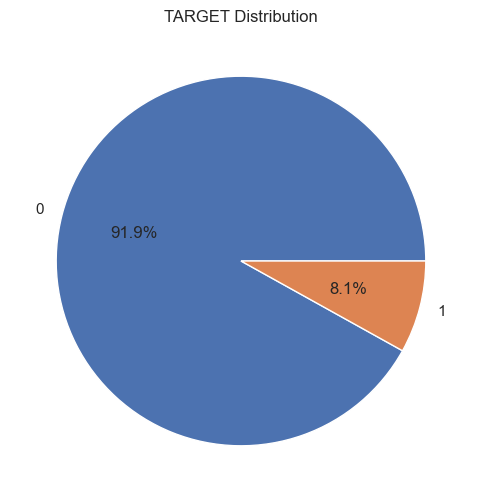

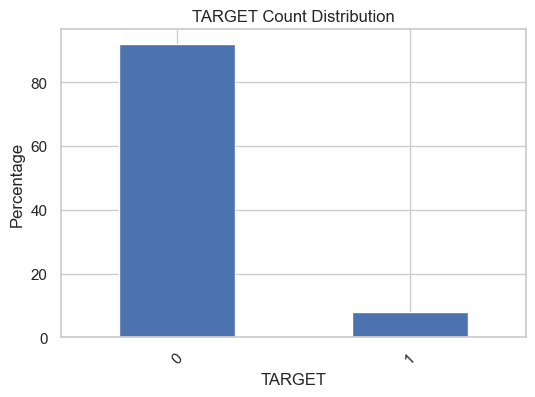

In [38]:
categorical_analysis(application_data, 'TARGET')


🔹 Column: CODE_GENDER
CODE_GENDER
F      65.834393
M      34.164306
XNA     0.001301
Name: proportion, dtype: float64


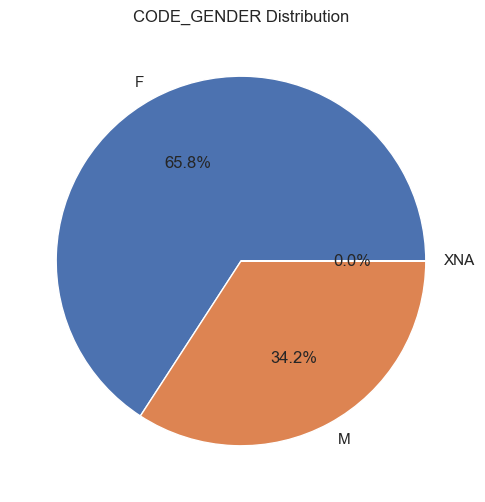

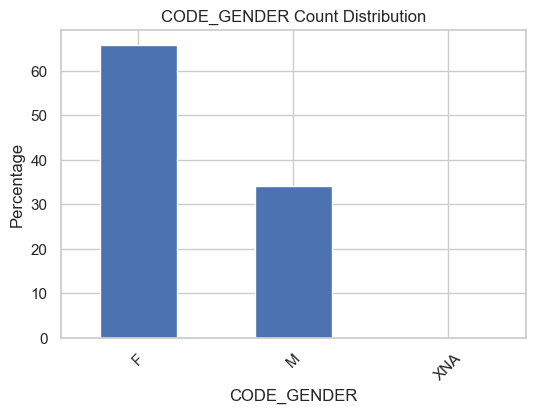

In [39]:
categorical_analysis(application_data, 'CODE_GENDER')


🔹 Column: NAME_INCOME_TYPE
NAME_INCOME_TYPE
Working                 51.631974
Commercial associate    23.289248
Pensioner               18.003258
State servant            7.057634
Unemployed               0.007154
Student                  0.005853
Businessman              0.003252
Maternity leave          0.001626
Name: proportion, dtype: float64


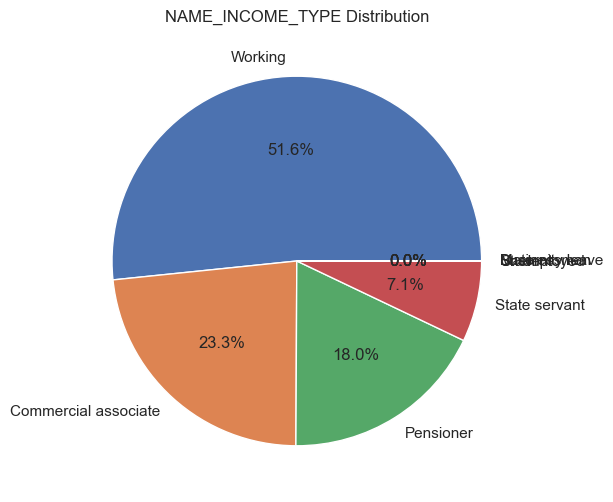

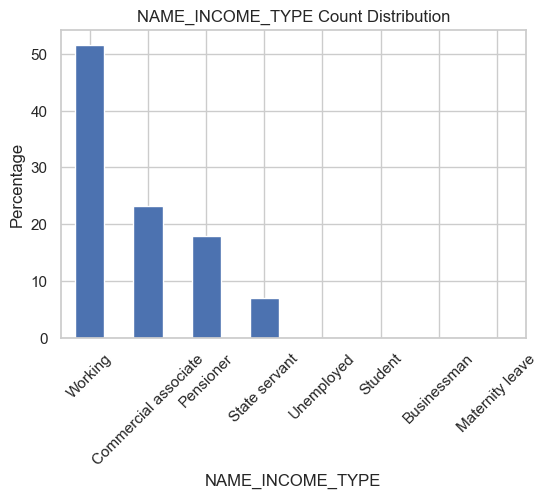

In [40]:
categorical_analysis(application_data, 'NAME_INCOME_TYPE')


🔹 Column: NAME_EDUCATION_TYPE
NAME_EDUCATION_TYPE
Secondary / secondary special    71.018923
Higher education                 24.344820
Incomplete higher                 3.341994
Lower secondary                   1.240931
Academic degree                   0.053331
Name: proportion, dtype: float64


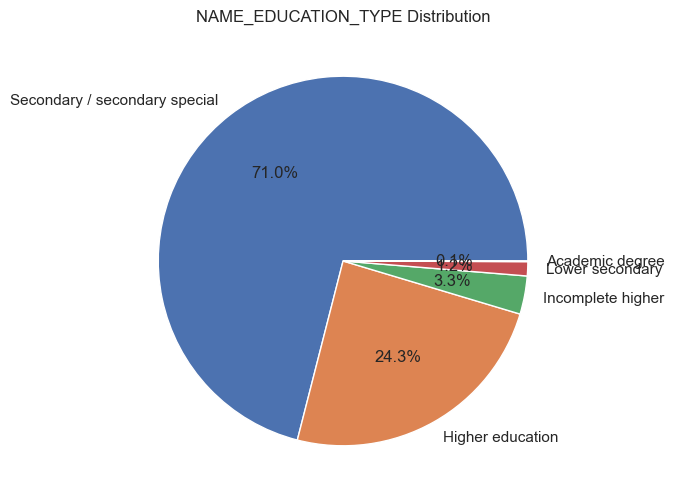

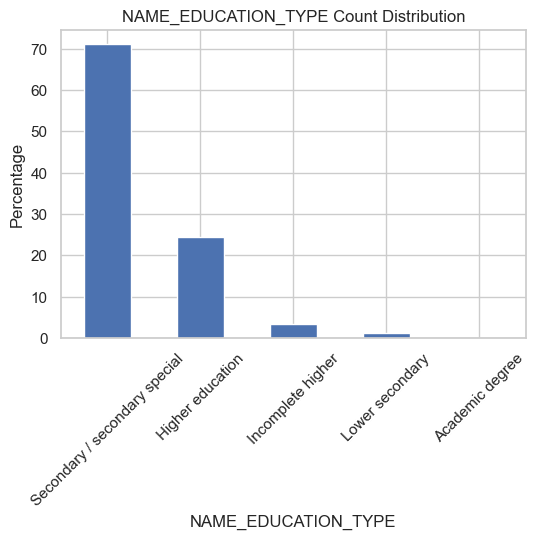

In [41]:
categorical_analysis(application_data, 'NAME_EDUCATION_TYPE')


🔹 Column: NAME_FAMILY_STATUS
NAME_FAMILY_STATUS
Married                 63.878040
Single / not married    14.778008
Civil marriage           9.682580
Separated                6.429038
Widow                    5.231683
Unknown                  0.000650
Name: proportion, dtype: float64


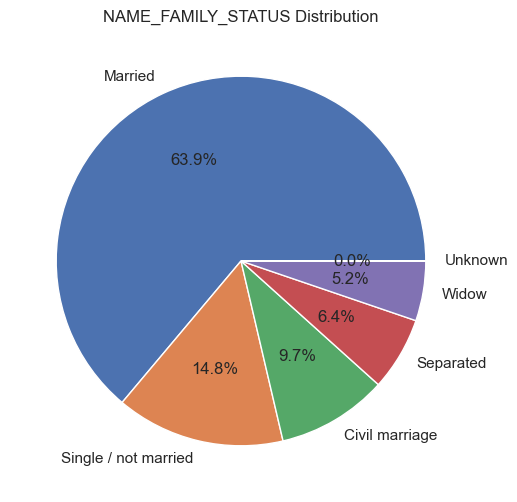

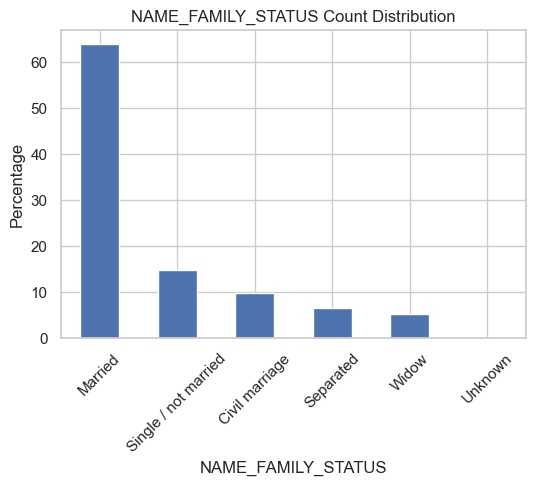

In [42]:
categorical_analysis(application_data, 'NAME_FAMILY_STATUS')


🔹 Column: NAME_HOUSING_TYPE
NAME_HOUSING_TYPE
House / apartment      88.734387
With parents            4.825844
Municipal apartment     3.636618
Rented apartment        1.587260
Office apartment        0.851026
Co-op apartment         0.364865
Name: proportion, dtype: float64


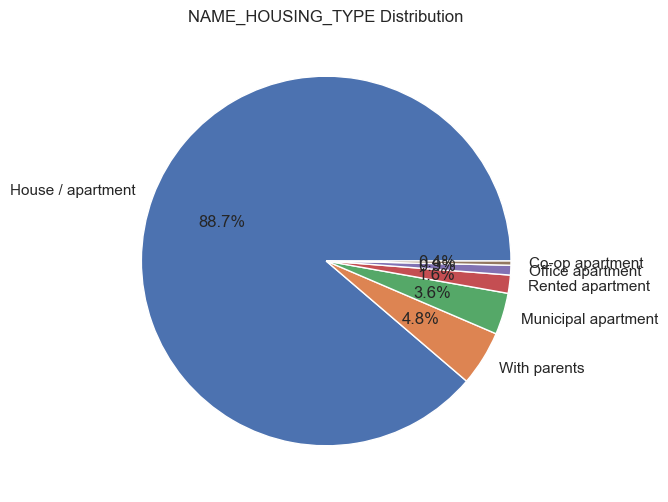

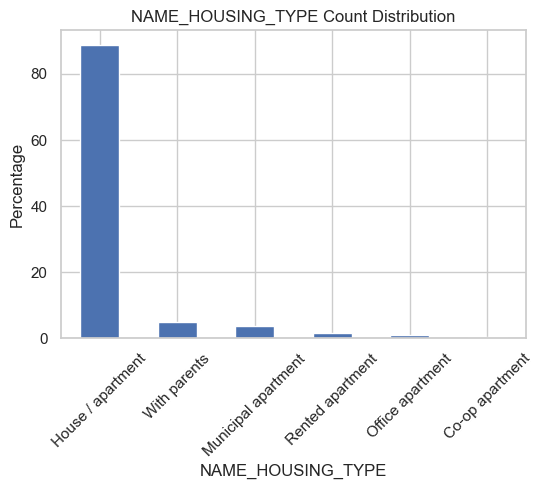

In [43]:
categorical_analysis(application_data, 'NAME_HOUSING_TYPE')

In [45]:
### Key Observations:
### - Dataset is highly imbalanced (TARGET)
### - Majority applicants are from [X] income group
### - Most applicants have [X] education level
### - Housing type is dominated by [X]

### These patterns will be useful for further bivariate analysis.

In [46]:
num_cols = application_data.select_dtypes(include=['int64','float64']).columns
num_cols

Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'FLAG_MOBIL', 'FLAG_EMP_PHONE',
       'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL',
       'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT',
       'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START',
       'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION',
       'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY',
       'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'EXT_SOURCE_2',
       'EXT_SOURCE_3', 'YEARS_BEGINEXPLUATATION_AVG',
       'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BEGINEXPLUATATION_MEDI',
       'TOTALAREA_MODE', 'OBS_30_CNT_SOCIAL_CIRCLE',
       'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE',
       'DEF_60_CNT_SOCIAL_CIRCLE', 'DAYS_LAST_PHONE_CHANGE', 'FLAG_DOCUMENT_2',
       'FLAG_D

In [47]:
def numerical_analysis(df, col):
    print(f"\n🔹 Column: {col}")
    
    # Basic stats
    print(df[col].describe())
    
    # Histogram
    plt.figure(figsize=(6,4))
    df[col].plot.hist(bins=30)
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.show()
    
    # Boxplot (Outliers)
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"{col} Boxplot")
    plt.show()


🔹 Column: AMT_INCOME_TOTAL
count    3.075110e+05
mean     1.687979e+05
std      2.371231e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.471500e+05
75%      2.025000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64


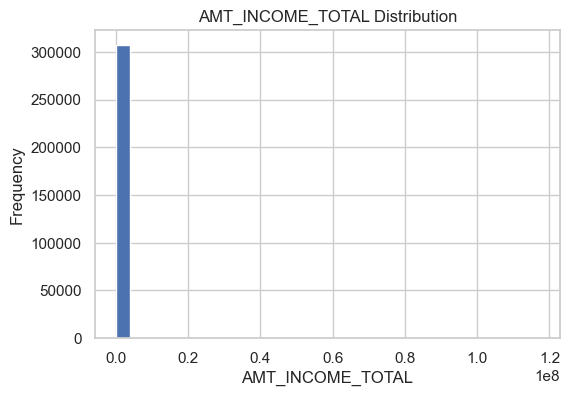

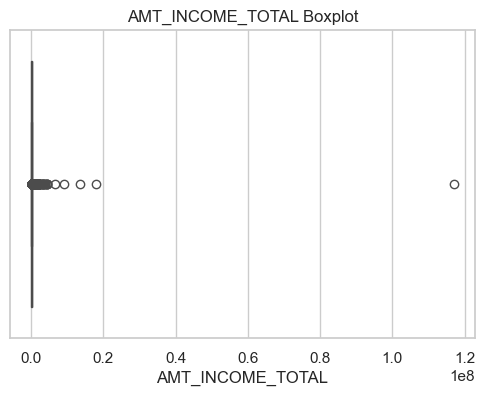

In [48]:
numerical_analysis(application_data, 'AMT_INCOME_TOTAL')


🔹 Column: AMT_CREDIT
count    3.075110e+05
mean     5.990260e+05
std      4.024908e+05
min      4.500000e+04
25%      2.700000e+05
50%      5.135310e+05
75%      8.086500e+05
max      4.050000e+06
Name: AMT_CREDIT, dtype: float64


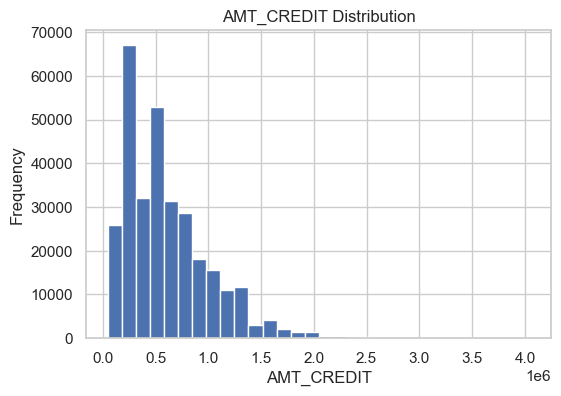

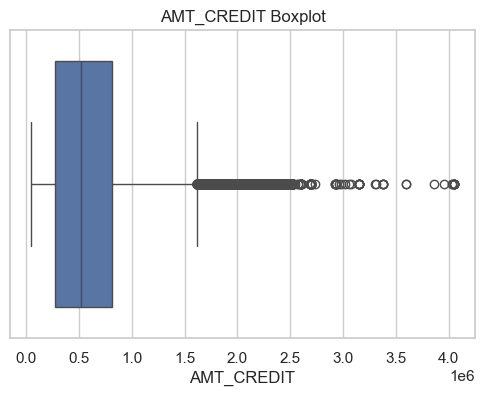

In [49]:
numerical_analysis(application_data, 'AMT_CREDIT')


🔹 Column: AMT_ANNUITY
count    307499.000000
mean      27108.573909
std       14493.737315
min        1615.500000
25%       16524.000000
50%       24903.000000
75%       34596.000000
max      258025.500000
Name: AMT_ANNUITY, dtype: float64


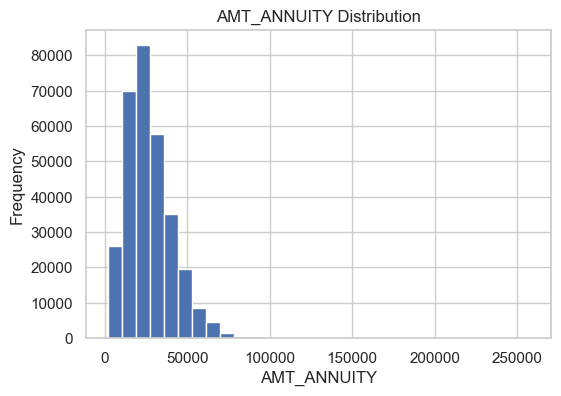

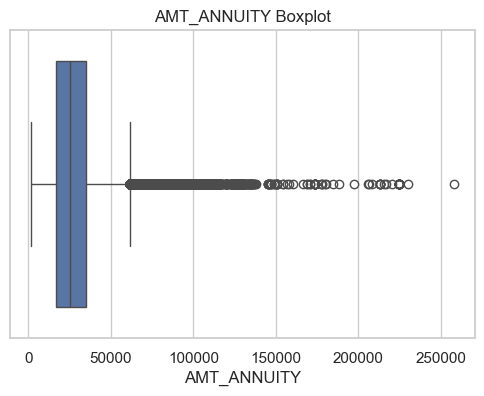

In [50]:
numerical_analysis(application_data, 'AMT_ANNUITY')


🔹 Column: AMT_GOODS_PRICE
count    3.072330e+05
mean     5.383962e+05
std      3.694465e+05
min      4.050000e+04
25%      2.385000e+05
50%      4.500000e+05
75%      6.795000e+05
max      4.050000e+06
Name: AMT_GOODS_PRICE, dtype: float64


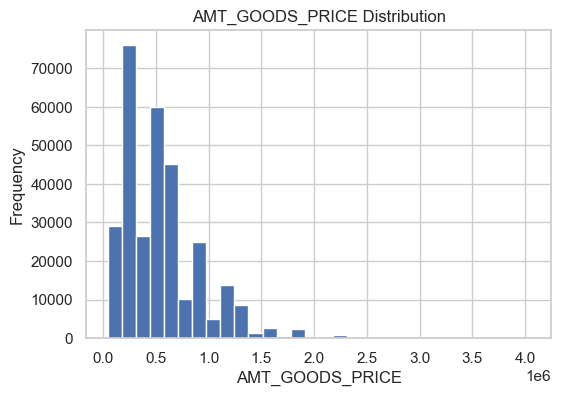

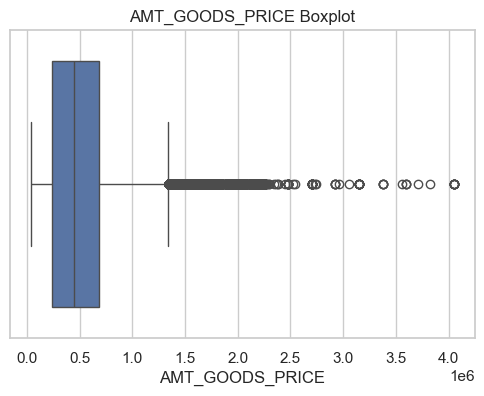

In [51]:
numerical_analysis(application_data, 'AMT_GOODS_PRICE')


🔹 Column: DAYS_BIRTH
count    307511.000000
mean      16036.995067
std        4363.988632
min        7489.000000
25%       12413.000000
50%       15750.000000
75%       19682.000000
max       25229.000000
Name: DAYS_BIRTH, dtype: float64


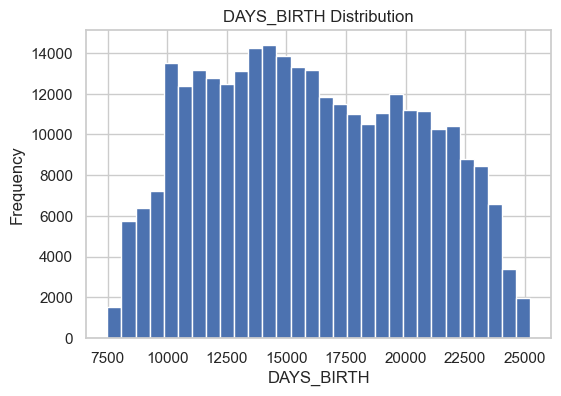

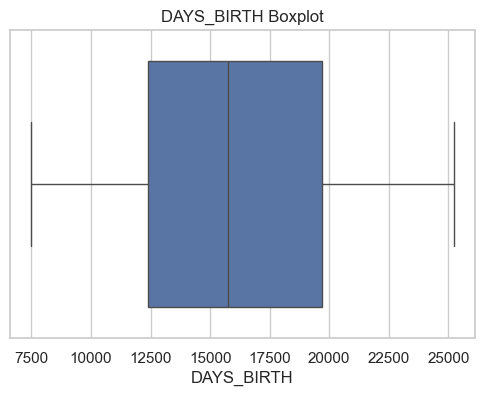

In [52]:
numerical_analysis(application_data, 'DAYS_BIRTH')


🔹 Column: DAYS_EMPLOYED
count    307511.000000
mean      67724.742149
std      139443.751806
min           0.000000
25%         933.000000
50%        2219.000000
75%        5707.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64


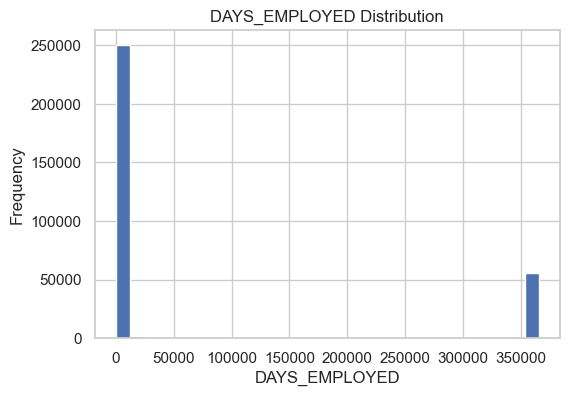

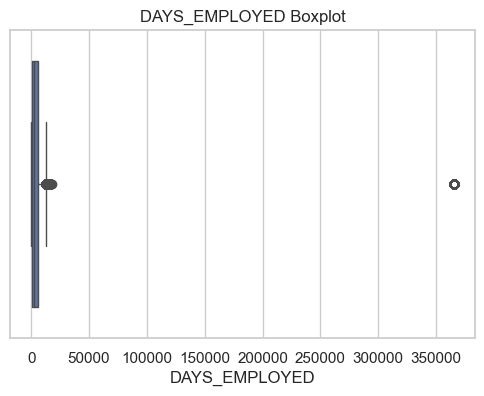

In [53]:
numerical_analysis(application_data, 'DAYS_EMPLOYED')

In [54]:
### Key Observations:
###- Income and credit distributions are highly skewed
###- Presence of extreme outliers in income and credit amount
###- Majority applicants fall under specific income/credit ranges
###- Age distribution shows most applicants are between X–Y years

###These findings indicate the need for scaling and outlier treatment in further analysis.

In [55]:
def cat_vs_target(df, col):
    temp = pd.crosstab(df[col], df['TARGET'], normalize='index') * 100
    
    print(f"\n🔹 {col} vs TARGET (%)")
    print(temp)
    
    # Stacked Bar Plot
    temp.plot(kind='bar', stacked=True, figsize=(6,4))
    plt.title(f"{col} vs Target")
    plt.ylabel('Percentage')
    plt.xticks(rotation=45)
    plt.show()

In [56]:
application_data['TARGET'].value_counts(normalize=True) * 100

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


🔹 CODE_GENDER vs TARGET (%)
TARGET                0          1
CODE_GENDER                       
F             93.000672   6.999328
M             89.858080  10.141920
XNA          100.000000   0.000000


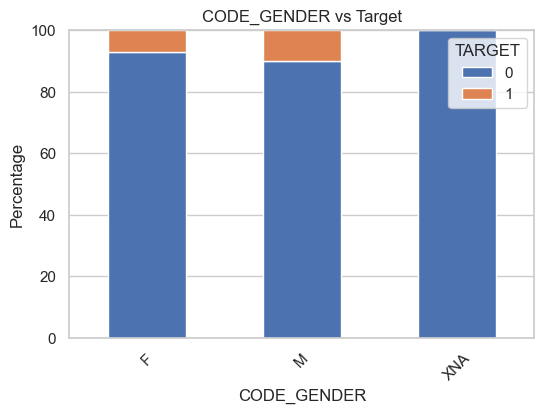

In [57]:
cat_vs_target(application_data, 'CODE_GENDER')


🔹 NAME_INCOME_TYPE vs TARGET (%)
TARGET                         0          1
NAME_INCOME_TYPE                           
Businessman           100.000000   0.000000
Commercial associate   92.515743   7.484257
Maternity leave        60.000000  40.000000
Pensioner              94.613634   5.386366
State servant          94.245035   5.754965
Student               100.000000   0.000000
Unemployed             63.636364  36.363636
Working                90.411528   9.588472


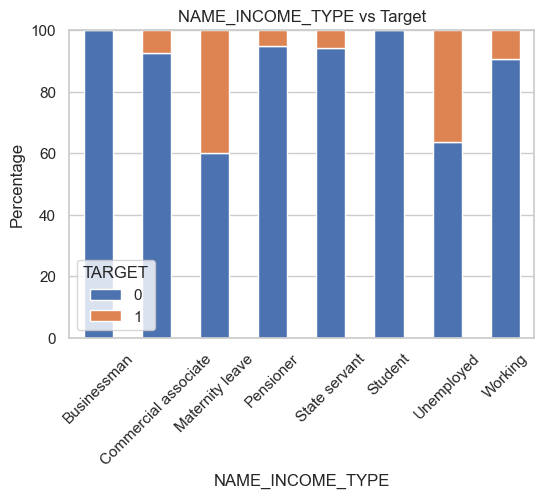

In [58]:
cat_vs_target(application_data, 'NAME_INCOME_TYPE')


🔹 NAME_EDUCATION_TYPE vs TARGET (%)
TARGET                                 0          1
NAME_EDUCATION_TYPE                                
Academic degree                98.170732   1.829268
Higher education               94.644885   5.355115
Incomplete higher              91.515034   8.484966
Lower secondary                89.072327  10.927673
Secondary / secondary special  91.060071   8.939929


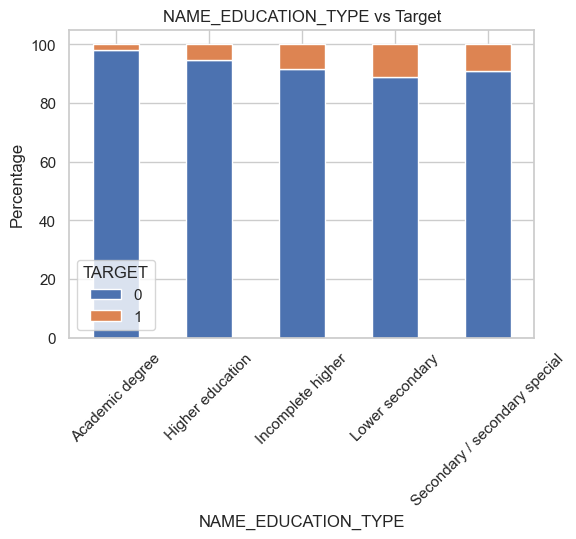

In [59]:
cat_vs_target(application_data, 'NAME_EDUCATION_TYPE')


🔹 NAME_FAMILY_STATUS vs TARGET (%)
TARGET                         0         1
NAME_FAMILY_STATUS                        
Civil marriage         90.055416  9.944584
Married                92.440132  7.559868
Separated              91.805766  8.194234
Single / not married   90.192325  9.807675
Unknown               100.000000  0.000000
Widow                  94.175783  5.824217


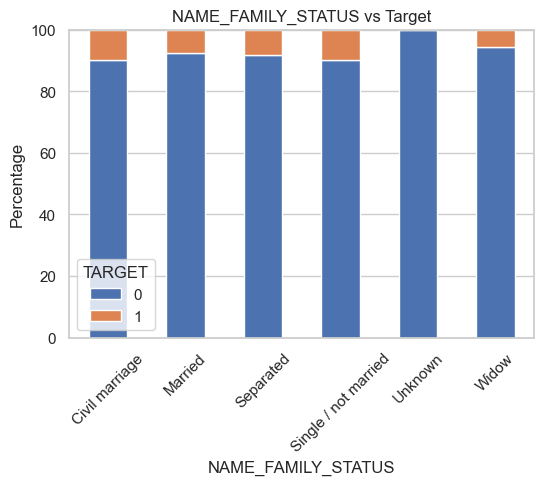

In [60]:
cat_vs_target(application_data, 'NAME_FAMILY_STATUS')


🔹 NAME_HOUSING_TYPE vs TARGET (%)
TARGET                       0          1
NAME_HOUSING_TYPE                        
Co-op apartment      92.067736   7.932264
House / apartment    92.204289   7.795711
Municipal apartment  91.460252   8.539748
Office apartment     93.427589   6.572411
Rented apartment     87.686949  12.313051
With parents         88.301887  11.698113


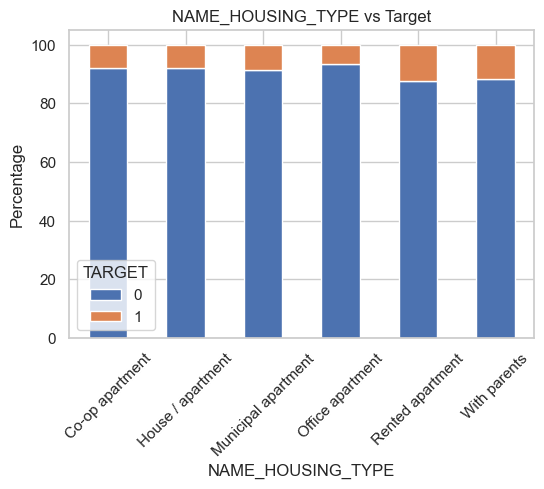

In [61]:
cat_vs_target(application_data, 'NAME_HOUSING_TYPE')

In [62]:
### Key Observations (Categorical vs TARGET):
###- Certain income groups show higher default rates
###- Education level appears to influence repayment behavior
###- Some housing categories indicate higher financial risk
###- Gender-based differences observed in default trends

###These features may be strong predictors for default risk.

In [63]:
def num_vs_target(df, col):
    plt.figure(figsize=(6,4))
    sns.boxplot(x='TARGET', y=col, data=df)
    plt.title(f"{col} vs TARGET")
    plt.show()

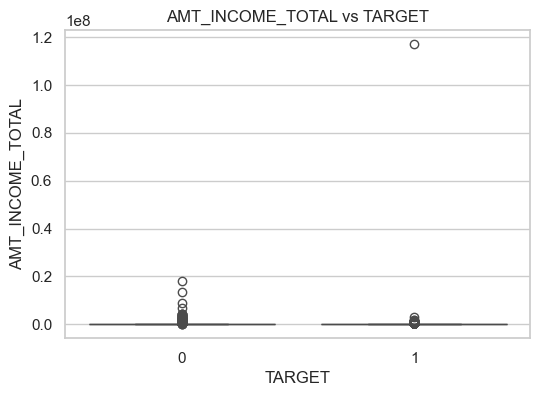

In [64]:
num_vs_target(application_data, 'AMT_INCOME_TOTAL')

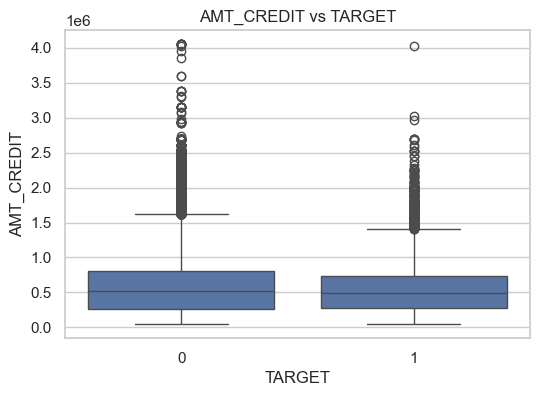

In [65]:
num_vs_target(application_data, 'AMT_CREDIT')

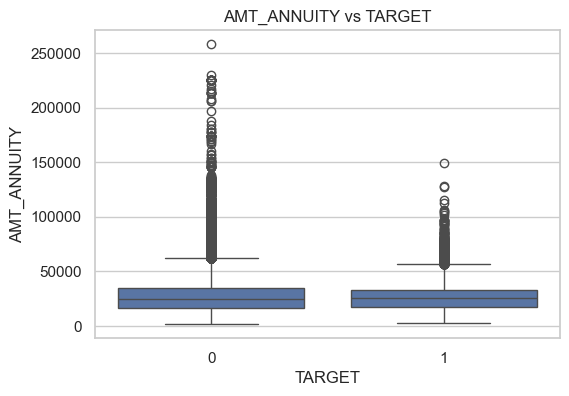

In [66]:
num_vs_target(application_data, 'AMT_ANNUITY')

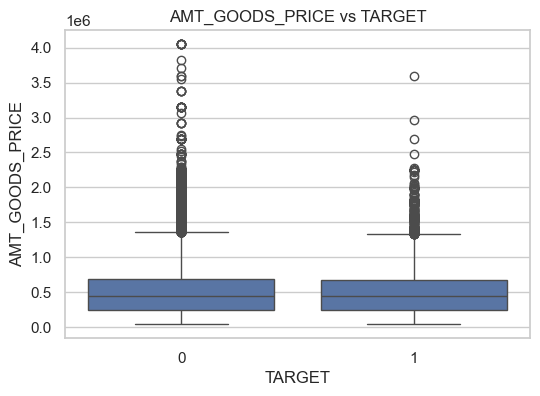

In [67]:
num_vs_target(application_data, 'AMT_GOODS_PRICE')

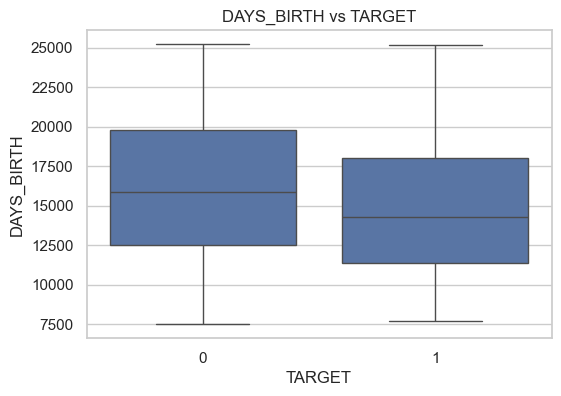

In [68]:
num_vs_target(application_data, 'DAYS_BIRTH')

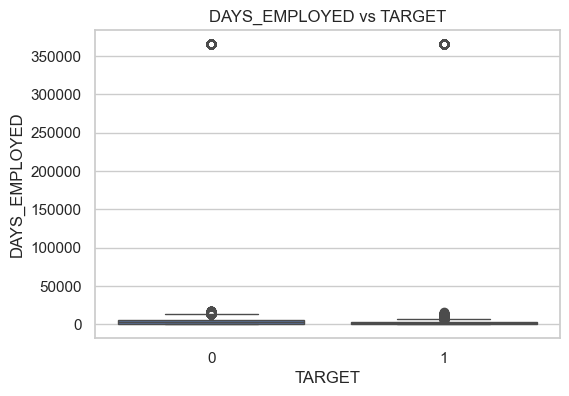

In [69]:
num_vs_target(application_data, 'DAYS_EMPLOYED')

In [70]:
### Key Observations (Numerical vs TARGET):
###- Defaulters tend to have lower income ranges
###- Higher credit amounts may be linked to higher risk
###- Younger applicants show slightly higher default tendency
###- Employment duration impacts repayment capability

###These numerical features are critical for predictive modeling.

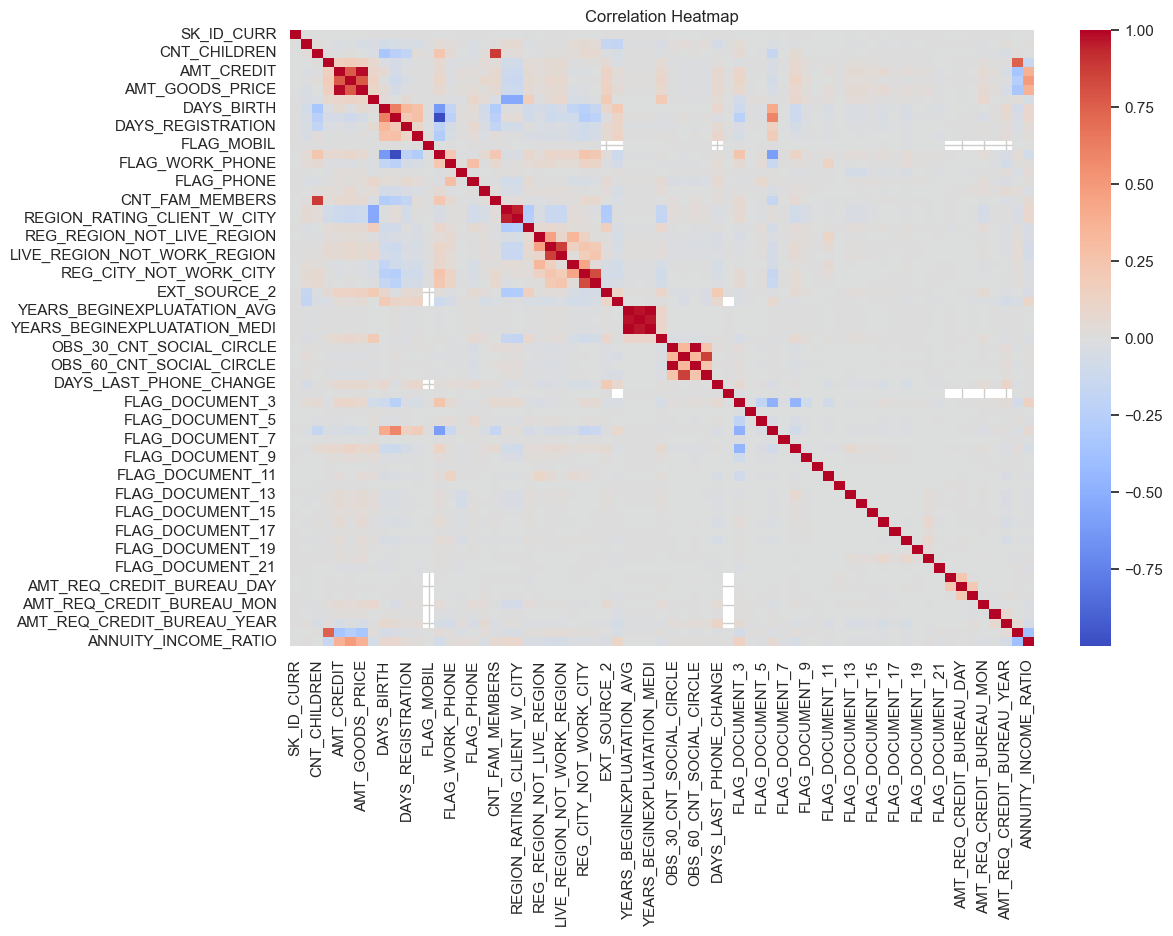

Top Positive Correlations:
 TARGET                         1.000000
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_DOCUMENT_3                0.044346
LIVE_CITY_NOT_WORK_CITY        0.032518
DEF_30_CNT_SOCIAL_CIRCLE       0.032248
DEF_60_CNT_SOCIAL_CIRCLE       0.031276
Name: TARGET, dtype: float64

Top Negative Correlations:
 TOTALAREA_MODE               -0.032596
REGION_POPULATION_RELATIVE   -0.037227
AMT_GOODS_PRICE              -0.039645
DAYS_REGISTRATION            -0.041975
DAYS_EMPLOYED                -0.047046
DAYS_ID_PUBLISH              -0.051457
DAYS_LAST_PHONE_CHANGE       -0.055218
DAYS_BIRTH                   -0.078239
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_3                 -0.178919
Name: TARGET, dtype: float64


In [76]:
# Step 1: Take only numeric columns
num_df = application_data.select_dtypes(include=['int64','float64'])

# Step 2: Correlation
corr = num_df.corr()

# Step 3: Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()

# Step 4: TARGET correlation
target_corr = corr['TARGET'].sort_values(ascending=False)

print("Top Positive Correlations:\n", target_corr.head(10))
print("\nTop Negative Correlations:\n", target_corr.tail(10))

In [77]:
target_corr = corr['TARGET'].sort_values(ascending=False)
target_corr

TARGET                         1.000000
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
                                 ...   
DAYS_ID_PUBLISH               -0.051457
DAYS_LAST_PHONE_CHANGE        -0.055218
DAYS_BIRTH                    -0.078239
EXT_SOURCE_2                  -0.160472
EXT_SOURCE_3                  -0.178919
Name: TARGET, Length: 67, dtype: float64

In [78]:
print("Top Positive Correlations:\n", target_corr.head(10))
print("\nTop Negative Correlations:\n", target_corr.tail(10))

Top Positive Correlations:
 TARGET                         1.000000
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_DOCUMENT_3                0.044346
LIVE_CITY_NOT_WORK_CITY        0.032518
DEF_30_CNT_SOCIAL_CIRCLE       0.032248
DEF_60_CNT_SOCIAL_CIRCLE       0.031276
Name: TARGET, dtype: float64

Top Negative Correlations:
 TOTALAREA_MODE               -0.032596
REGION_POPULATION_RELATIVE   -0.037227
AMT_GOODS_PRICE              -0.039645
DAYS_REGISTRATION            -0.041975
DAYS_EMPLOYED                -0.047046
DAYS_ID_PUBLISH              -0.051457
DAYS_LAST_PHONE_CHANGE       -0.055218
DAYS_BIRTH                   -0.078239
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_3                 -0.178919
Name: TARGET, dtype: float64


In [73]:
### Key Observations (Correlation):
### - Features like [X] show strong positive correlation with TARGET → higher default risk
### - Features like [Y] show negative correlation → safer applicants
### - Most features have low correlation → indicates need for advanced modeling

### Correlation alone is not sufficient but helps in feature selection.

In [79]:
application_data['INCOME_CREDIT_RATIO'] = application_data['AMT_INCOME_TOTAL'] / application_data['AMT_CREDIT']

application_data['ANNUITY_INCOME_RATIO'] = application_data['AMT_ANNUITY'] / application_data['AMT_INCOME_TOTAL']

In [80]:
### Key Observations (Bivariate Analysis):

### - Certain income groups show higher default rates
### - Applicants with lower income tend to default more
### - Younger customers show slightly higher risk
### - Employment duration impacts repayment capability
### - Some housing and family categories indicate financial instability

### These features are important indicators of default risk.

In [81]:
## Correlation Analysis

In [82]:
# Take only numerical columns
num_df = application_data.select_dtypes(include=['int64','float64'])

# Correlation matrix
corr = num_df.corr()

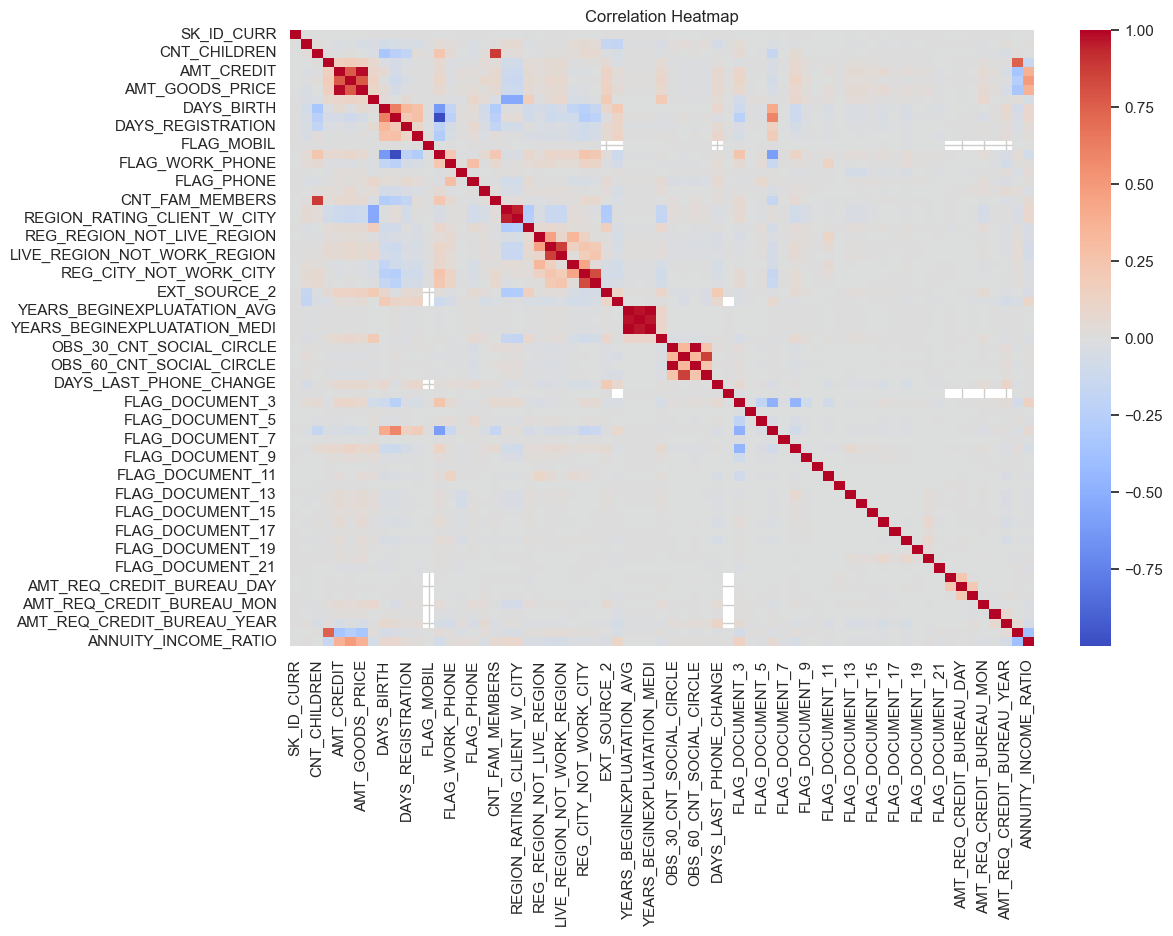

In [83]:
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()

In [84]:
target_corr = corr['TARGET'].sort_values(ascending=False)

print("Top Positive Correlations:\n", target_corr.head(10))
print("\nTop Negative Correlations:\n", target_corr.tail(10))

Top Positive Correlations:
 TARGET                         1.000000
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_DOCUMENT_3                0.044346
LIVE_CITY_NOT_WORK_CITY        0.032518
DEF_30_CNT_SOCIAL_CIRCLE       0.032248
DEF_60_CNT_SOCIAL_CIRCLE       0.031276
Name: TARGET, dtype: float64

Top Negative Correlations:
 TOTALAREA_MODE               -0.032596
REGION_POPULATION_RELATIVE   -0.037227
AMT_GOODS_PRICE              -0.039645
DAYS_REGISTRATION            -0.041975
DAYS_EMPLOYED                -0.047046
DAYS_ID_PUBLISH              -0.051457
DAYS_LAST_PHONE_CHANGE       -0.055218
DAYS_BIRTH                   -0.078239
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_3                 -0.178919
Name: TARGET, dtype: float64


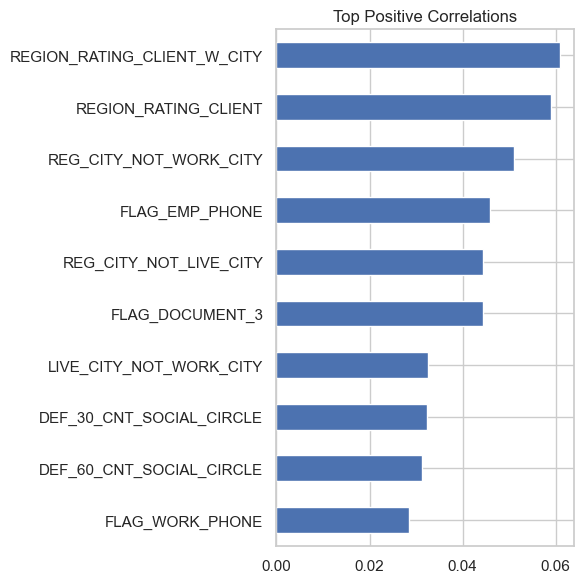

In [86]:
top_features = target_corr[1:].abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(6,6))

target_corr[1:].sort_values().tail(10).plot(kind='barh')

plt.title("Top Positive Correlations")
plt.tight_layout()
plt.show()

In [87]:
## Final Insights and Business Recommendations

In [88]:
### Overall Findings:

###- The dataset is highly imbalanced, with fewer defaulters compared to non-defaulters
###- Income, credit amount, and annuity play a major role in determining default risk
###- Demographic factors like education, occupation, and housing type influence repayment behavior
###- Most features show weak linear correlation, indicating complex relationships between variables

In [89]:
### High-Risk Customers:

###Customers are more likely to default if they:
###- Have lower income levels
###- Apply for higher credit amounts relative to their income
###- Have shorter employment duration
###- Belong to certain income types (e.g., unstable or irregular income)
###- Fall into younger age groups

In [90]:
### Low-Risk Customers:

###ustomers are less likely to default if they:
###- Have stable and higher income
###- Have longer employment history
###- Apply for moderate and manageable credit amounts
###- Show consistent financial behavior

In [91]:
### Key Features Influencing Default:

### - AMT_INCOME_TOTAL (Income)
### - AMT_CREDIT (Loan Amount)
### - AMT_ANNUITY (Repayment Amount)
### - DAYS_EMPLOYED (Employment Duration)
### - DAYS_BIRTH (Age)

### These features are important indicators of a customer's financial stability and repayment capacity.

In [92]:
### Business Recommendations:

### - Perform stricter verification for applicants with low income and high credit requests
### - Introduce risk-based pricing (higher interest for high-risk customers)
### - Encourage stable employment verification before loan approval
### - Use data-driven scoring systems to evaluate customer risk
### - Monitor high-risk segments more closely after loan approval

In [94]:
### Conclusion:

### This analysis provides valuable insights into customer behavior and default patterns. 
###By leveraging these findings, financial institutions can improve risk assessment, reduce defaults, and make more informed lending decisions.

In [95]:
# Take only numerical columns
df_model = application_data.select_dtypes(include=['int64','float64'])

# Drop missing values (simple approach)
df_model = df_model.dropna()

In [96]:
X = df_model.drop('TARGET', axis=1)
y = df_model['TARGET']

In [97]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [98]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [99]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [100]:
y_pred = model.predict(X_test)

In [101]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9329803208725204

Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.97     23609
           1       0.56      0.00      0.01      1697

    accuracy                           0.93     25306
   macro avg       0.74      0.50      0.49     25306
weighted avg       0.91      0.93      0.90     25306


Confusion Matrix:
 [[23605     4]
 [ 1692     5]]


In [102]:
# Optional: ROC-AUC
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

ROC-AUC Score: 0.7246873807625025


In [103]:
### Model Summary:

### - A Logistic Regression model was used as a baseline for predicting loan default risk
### - The dataset was preprocessed by selecting numerical features and handling missing values
### - Feature scaling was applied to improve model performance
### - The model was evaluated using accuracy, confusion matrix, classification report, and ROC-AUC score
### - The model provides a basic understanding of customer risk and serves as a foundation for further improvements